# Train CNN Classifier + Grad-CAM for Histopathology Images

This notebook trains the first part of your pipeline:

```text
Input Image
    ->
[CNN Classifier + Grad-CAM] -> WHAT: cancer / healthy / stage + WHERE: heatmap
```

Expected dataset layout (oral cancer and healthy oral folders are **excluded**):

```text
cancersv2/
  train/
    cancer_blood_stage_1/
    cancer_blood_stage_2/
    cancer_blood_stage_3/
    cancer_breast/
    cancer_colon/
    cancer_kidney/
    cancer_lung_stage_1/
    cancer_lung_stage_2/
    healthy_blood/
    healthy_breast/
    healthy_colon/
    healthy_kidney/
    healthy_lung/
  val/  (same structure)
```

The notebook trains a **13-class** fine-tuned **ResNet50** classifier with Grad-CAM.


## 1. Install Libraries

Run this only if your environment does not already have the packages.

In [ ]:
# Uncomment if needed:
!pip install -q torch torchvision scikit-learn matplotlib pandas pillow tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cp /content/drive/MyDrive/cancersv4.zip /content/

In [ ]:
!unzip /content/cancersv4.zip -d /content/images

Streaming output truncated to the last 5000 lines.
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0617.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0618.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0619.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0620.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0621.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0622.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0623.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0624.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0625.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0626.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_0627.jpg  
  inflating: /content/images/cancersv4/train/healthy_colon/colon_bnt_

## 2. Imports and Settings

In [ ]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
print('Running in Colab:', IN_COLAB)
print('Device:', DEVICE)
print('Mixed precision:', USE_AMP)
if DEVICE.type != 'cuda':
    print('For faster training in Colab, go to Runtime > Change runtime type > GPU.')

Running in Colab: True
Device: cuda
Mixed precision: True


## 3. Dataset Path

In Colab, put your dataset in Google Drive or upload/unzip it into `/content`. Then set `DATA_ROOT` to the folder containing `train` and `val`.

In [ ]:
# Colab setup
# Option 1: Use Google Drive. Set USE_GOOGLE_DRIVE = True and edit DRIVE_DATASET_DIR.
# Option 2: Upload/unzip the dataset into /content and edit COLAB_DATASET_DIR.
USE_GOOGLE_DRIVE = False

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

# EDIT ONE OF THESE PATHS
# DRIVE_DATASET_DIR = Path('/content/drive/MyDrive/cancersv2')
COLAB_DATASET_DIR = Path('/content/images/cancersv4')

if IN_COLAB:
    DATA_ROOT = Path('/content/images/cancersv4')
    OUTPUT_DIR = Path('/content/drive/MyDrive/siamese_multi') if USE_GOOGLE_DRIVE else Path('/content/drive/MyDrive/siamese_multi')
else:
    DATA_ROOT = Path('/content/images/cancersv4')
    OUTPUT_DIR = DATA_ROOT / 'output'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'resnet50_histopathology'
MODEL_SAVE_PATH = str(OUTPUT_DIR / 'best_resnet50_histopathology_gradcam_classifier.pth')
CHECKPOINT_PATH = OUTPUT_DIR / 'last_resnet50_histopathology_checkpoint.pth'

# Folders to skip - oral cancer and healthy oral are excluded
EXCLUDED_FOLDERS = {'cancer_oral', 'healthy_oral'}

IMG_SIZE        = 512
BATCH_SIZE      = 16      # ResNet50 at 512px is memory hungry; raise to 24 if your GPU allows it
EPOCHS          = 60      # longer fine-tuning usually helps histopathology datasets
LEARNING_RATE   = 3e-4
WEIGHT_DECAY    = 2e-4
LABEL_SMOOTHING = 0.08
DROPOUT         = 0.50
NUM_WORKERS     = 2 if IN_COLAB else 0

# Regularisation that forces learning from more than one tissue region.
MIXUP_ALPHA     = 0.20
CUTMIX_ALPHA    = 1.00
MIX_PROB        = 0.50
CUTMIX_PROB     = 0.50

# Use ALL available images - do not cap per folder.
# Set VERIFY_EXACT_IMAGE_COUNTS = False so folders with fewer images are accepted.
VERIFY_EXACT_IMAGE_COUNTS = False
TRAIN_IMAGES_PER_FOLDER   = None   # None = use every image found
VAL_IMAGES_PER_FOLDER     = None   # None = use every image found

print('Dataset:', DATA_ROOT)
print('Excluded folders:', EXCLUDED_FOLDERS)
print('Backbone:', MODEL_NAME)
print('Model will save to:', MODEL_SAVE_PATH)
print('Resume checkpoint will save to:', CHECKPOINT_PATH)


Dataset: /content/images/cancersv4
Excluded folders: {'cancer_oral', 'healthy_oral'}
Backbone: resnet50_histopathology
Model will save to: /content/drive/MyDrive/siamese_multi/best_resnet50_histopathology_gradcam_classifier.pth
Resume checkpoint will save to: /content/drive/MyDrive/siamese_multi/last_resnet50_histopathology_checkpoint.pth


## 4. Read Images and Create Labels

The notebook uses the class folders found inside `C:\Users\m4noi\Downloads\cancersv2\train`.

Each class must also exist as a matching folder inside `val`. Image counts are displayed per folder so you can confirm the dataset before training.

In [ ]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

SPLIT_IMAGE_TARGETS = {
    'train': TRAIN_IMAGES_PER_FOLDER,
    'val': VAL_IMAGES_PER_FOLDER,
}

def normalize_name(text):
    return text.lower().replace(' ', '_').replace('-', '_')

def discover_class_folders():
    train_dir = DATA_ROOT / 'train'
    if not train_dir.exists():
        raise FileNotFoundError(f'Missing expected folder: {train_dir}')

    class_folders = sorted(
        [
            normalize_name(p.name)
            for p in train_dir.iterdir()
            if p.is_dir() and normalize_name(p.name) not in EXCLUDED_FOLDERS
        ],
        key=normalize_name,
    )
    if not class_folders:
        raise FileNotFoundError(f'No class folders found inside: {train_dir}')
    return class_folders

REQUIRED_CLASS_FOLDERS = discover_class_folders()

print('Class folders discovered from train:')
for class_folder in REQUIRED_CLASS_FOLDERS:
    print('-', class_folder)

def parse_stage(remainder):
    if '_stage_' not in remainder:
        return remainder, None
    organ, stage_value = remainder.split('_stage_', 1)
    return organ, f'stage {stage_value.replace("_", " ")}'

def get_class_metadata(class_dir):
    folder = normalize_name(class_dir.name)

    if folder.startswith('cancer_'):
        diagnosis = 'cancer'
        organ, stage = parse_stage(folder[len('cancer_'):])
        display_name = f'{organ.replace("_", " ").title()} Cancer'
        if stage:
            display_name = f'{display_name} - {stage.title()}'
    elif folder.startswith(('healthy_', 'normal_')):
        diagnosis = 'healthy'
        prefix = 'healthy_' if folder.startswith('healthy_') else 'normal_'
        organ = folder[len(prefix):]
        stage = None
        display_name = f'Healthy {organ.replace("_", " ").title()}'
    else:
        diagnosis = 'unknown'
        organ = folder
        stage = None
        display_name = folder.replace('_', ' ').title()

    class_name = folder
    organ = organ.replace('_', ' ')
    return class_name, display_name, diagnosis, organ, stage, folder

def get_split_class_dirs(split_name):
    split_dir = DATA_ROOT / split_name
    if not split_dir.exists():
        raise FileNotFoundError(f'Missing expected folder: {split_dir}')

    class_dirs_by_name = {
        normalize_name(p.name): p
        for p in split_dir.iterdir()
        if p.is_dir() and normalize_name(p.name) not in EXCLUDED_FOLDERS
    }
    missing = [name for name in REQUIRED_CLASS_FOLDERS if name not in class_dirs_by_name]
    extra = sorted([name for name in class_dirs_by_name if name not in REQUIRED_CLASS_FOLDERS])

    if missing or extra:
        raise ValueError(
            f'{split_name} folders must match the train class folders exactly.\n'
            f'Missing: {missing}\n'
            f'Extra: {extra}\n'
            f'Required: {REQUIRED_CLASS_FOLDERS}'
        )

    return [class_dirs_by_name[name] for name in REQUIRED_CLASS_FOLDERS]

train_class_dirs = get_split_class_dirs('train')
CLASS_NAMES = [get_class_metadata(class_dir)[0] for class_dir in train_class_dirs]
CLASS_DISPLAY_NAMES = [get_class_metadata(class_dir)[1] for class_dir in train_class_dirs]
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

print(f'Total classes: {NUM_CLASSES}')
for idx, name in enumerate(CLASS_DISPLAY_NAMES):
    print(f'{idx}: {name}')

def load_split(split_name, expected_per_folder=None):
    split_dir = DATA_ROOT / split_name
    if not split_dir.exists():
        raise FileNotFoundError(f'Missing expected folder: {split_dir}')

    rows = []
    class_dirs = get_split_class_dirs(split_name)
    split_class_names = [get_class_metadata(class_dir)[0] for class_dir in class_dirs]
    if split_class_names != CLASS_NAMES:
        raise ValueError(
            f'{split_name} folders must match the train classes.\n'
            f'train: {CLASS_NAMES}\n{split_name}: {split_class_names}'
        )

    for class_dir in class_dirs:
        class_name, display_name, diagnosis, organ, stage, folder = get_class_metadata(class_dir)
        label = CLASS_TO_IDX[class_name]
        image_paths = sorted([p for p in class_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS])
        if VERIFY_EXACT_IMAGE_COUNTS and expected_per_folder is not None and len(image_paths) != expected_per_folder:
            raise ValueError(
                f'{class_dir} has {len(image_paths)} images; expected {expected_per_folder}.'
            )
        if not image_paths:
            raise ValueError(f'No images found in {class_dir}')

        for path in image_paths:
            rows.append({
                'path': str(path),
                'split': split_name,
                'label': label,
                'label_name': class_name,
                'display_name': display_name,
                'diagnosis': diagnosis,
                'organ': organ,
                'stage': stage,
                'folder': folder,
            })
    return pd.DataFrame(rows)

train_df = load_split('train', SPLIT_IMAGE_TARGETS['train'])
val_df = load_split('val', SPLIT_IMAGE_TARGETS['val'])
df = pd.concat([train_df, val_df], ignore_index=True)

print(f'Found {len(train_df)} training images')
print(f'Found {len(val_df)} validation images')
display(df.groupby(['split', 'label', 'label_name', 'display_name', 'diagnosis', 'organ', 'stage'], dropna=False).size().reset_index(name='n'))

Class folders discovered from train:
- cancer_blood_stage_1
- cancer_blood_stage_2
- cancer_blood_stage_3
- cancer_breast
- cancer_colon
- cancer_kidney
- cancer_lung_stage_1
- cancer_lung_stage_2
- healthy_blood
- healthy_breast
- healthy_colon
- healthy_kidney
- healthy_lung
Total classes: 13
0: Blood Cancer - Stage 1
1: Blood Cancer - Stage 2
2: Blood Cancer - Stage 3
3: Breast Cancer
4: Colon Cancer
5: Kidney Cancer
6: Lung Cancer - Stage 1
7: Lung Cancer - Stage 2
8: Healthy Blood
9: Healthy Breast
10: Healthy Colon
11: Healthy Kidney
12: Healthy Lung
Found 13000 training images
Found 2600 validation images


,split,label,label_name,display_name,diagnosis,organ,stage,n
0,train,0,cancer_blood_stage_1,Blood Cancer - Stage 1,cancer,blood,stage 1,1000
1,train,1,cancer_blood_stage_2,Blood Cancer - Stage 2,cancer,blood,stage 2,1000
2,train,2,cancer_blood_stage_3,Blood Cancer - Stage 3,cancer,blood,stage 3,1000
3,train,3,cancer_breast,Breast Cancer,cancer,breast,NaN,1000
4,train,4,cancer_colon,Colon Cancer,cancer,colon,NaN,1000
5,train,5,cancer_kidney,Kidney Cancer,cancer,kidney,NaN,1000
6,train,6,cancer_lung_stage_1,Lung Cancer - Stage 1,cancer,lung,stage 1,1000
7,train,7,cancer_lung_stage_2,Lung Cancer - Stage 2,cancer,lung,stage 2,1000
8,train,8,healthy_blood,Healthy Blood,healthy,blood,NaN,1000
9,train,9,healthy_breast,Healthy Breast,healthy,breast,NaN,1000


## 5. Confirm Train / Validation Data

The notebook now uses every folder under `cancersv2/train` as a class and checks that `cancersv2/val` has the same folders. Image counts are displayed per folder so you can spot class imbalance before training.

In [ ]:
print('Total classes:', NUM_CLASSES)
print('Train images:', len(train_df))
print('Validation images:', len(val_df))
display(train_df.groupby(['folder', 'label_name', 'display_name', 'organ', 'stage'], dropna=False).size().reset_index(name='train_n'))
display(val_df.groupby(['folder', 'label_name', 'display_name', 'organ', 'stage'], dropna=False).size().reset_index(name='val_n'))

Total classes: 13
Train images: 13000
Validation images: 2600


,folder,label_name,display_name,organ,stage,train_n
0,cancer_blood_stage_1,cancer_blood_stage_1,Blood Cancer - Stage 1,blood,stage 1,1000
1,cancer_blood_stage_2,cancer_blood_stage_2,Blood Cancer - Stage 2,blood,stage 2,1000
2,cancer_blood_stage_3,cancer_blood_stage_3,Blood Cancer - Stage 3,blood,stage 3,1000
3,cancer_breast,cancer_breast,Breast Cancer,breast,NaN,1000
4,cancer_colon,cancer_colon,Colon Cancer,colon,NaN,1000
5,cancer_kidney,cancer_kidney,Kidney Cancer,kidney,NaN,1000
6,cancer_lung_stage_1,cancer_lung_stage_1,Lung Cancer - Stage 1,lung,stage 1,1000
7,cancer_lung_stage_2,cancer_lung_stage_2,Lung Cancer - Stage 2,lung,stage 2,1000
8,healthy_blood,healthy_blood,Healthy Blood,blood,NaN,1000
9,healthy_breast,healthy_breast,Healthy Breast,breast,NaN,1000


,folder,label_name,display_name,organ,stage,val_n
0,cancer_blood_stage_1,cancer_blood_stage_1,Blood Cancer - Stage 1,blood,stage 1,200
1,cancer_blood_stage_2,cancer_blood_stage_2,Blood Cancer - Stage 2,blood,stage 2,200
2,cancer_blood_stage_3,cancer_blood_stage_3,Blood Cancer - Stage 3,blood,stage 3,200
3,cancer_breast,cancer_breast,Breast Cancer,breast,NaN,200
4,cancer_colon,cancer_colon,Colon Cancer,colon,NaN,200
5,cancer_kidney,cancer_kidney,Kidney Cancer,kidney,NaN,200
6,cancer_lung_stage_1,cancer_lung_stage_1,Lung Cancer - Stage 1,lung,stage 1,200
7,cancer_lung_stage_2,cancer_lung_stage_2,Lung Cancer - Stage 2,lung,stage 2,200
8,healthy_blood,healthy_blood,Healthy Blood,blood,NaN,200
9,healthy_breast,healthy_breast,Healthy Breast,breast,NaN,200


## 6. Dataset and Augmentation

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class RandomHistologyStainJitter:
    """Lightweight stain augmentation for H&E-like colour variation.
    Randomises per-channel brightness/contrast so the model cannot rely
    on a single staining style from one lab or scanner.
    """
    def __init__(self, alpha_range=(0.85, 1.15), beta_range=(-0.08, 0.08), p=0.85):
        self.alpha_range = alpha_range
        self.beta_range = beta_range
        self.p = p

    def __call__(self, image):
        if random.random() > self.p:
            return image
        arr = np.asarray(image).astype(np.float32) / 255.0
        alpha = np.random.uniform(self.alpha_range[0], self.alpha_range[1], size=(1, 1, 3))
        beta = np.random.uniform(self.beta_range[0], self.beta_range[1], size=(1, 1, 3))
        arr = np.clip(arr * alpha + beta, 0.0, 1.0)
        return Image.fromarray((arr * 255).astype(np.uint8))

class RandomGridMask:
    """Hide small grid regions so ResNet50 must use the rest of the tissue context."""
    def __init__(self, p=0.45, ratio=0.45, grid_range=(72, 144)):
        self.p = p
        self.ratio = ratio
        self.grid_range = grid_range

    def __call__(self, tensor):
        if random.random() > self.p:
            return tensor
        _, h, w = tensor.shape
        grid = random.randint(*self.grid_range)
        cut = max(1, int(grid * self.ratio))
        offset_y = random.randint(0, grid - 1)
        offset_x = random.randint(0, grid - 1)
        mask = torch.ones((h, w), dtype=tensor.dtype, device=tensor.device)
        for y in range(offset_y, h, grid):
            mask[y:min(y + cut, h), :] = 0
        for x in range(offset_x, w, grid):
            mask[:, x:min(x + cut, w)] = 0
        return tensor * mask.unsqueeze(0)

train_transforms = transforms.Compose([
    # RandomResizedCrop simulates different magnification levels seen across datasets
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.60, 1.00), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    # Stain jitter is the single most important augmentation for cross-dataset generalisation
    RandomHistologyStainJitter(p=0.85),
    # Hue range raised to 0.15 to cover broader staining variation between labs
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.35, hue=0.15),
    # Randomly convert to grayscale - forces model to rely on texture, not just colour
    transforms.RandomGrayscale(p=0.10),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=7, sigma=(0.1, 2.5))], p=0.30),
    transforms.ToTensor(),
    RandomGridMask(p=0.45, ratio=0.40, grid_range=(80, 160)),
    transforms.RandomErasing(p=0.45, scale=(0.03, 0.18), ratio=(0.3, 3.3), value='random'),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.08)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# TTA transforms: lighter augmentation used at inference time only
tta_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.00)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    RandomHistologyStainJitter(p=0.70),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class HistologyClassifierDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row.path).convert('RGB')
        image = self.transform(image)
        label = torch.tensor(row.label, dtype=torch.long)
        return image, label, row.path, row.organ

class_counts = train_df['label'].value_counts().sort_index().to_numpy()
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = train_df['label'].map(lambda label: class_weights[int(label)]).to_numpy()
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    HistologyClassifierDataset(train_df, train_transforms),
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
)

val_loader = DataLoader(
    HistologyClassifierDataset(val_df, val_transforms),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
)

print('Class counts:', dict(zip(CLASS_DISPLAY_NAMES, class_counts)))


Class counts: {'Blood Cancer - Stage 1': np.int64(1000), 'Blood Cancer - Stage 2': np.int64(1000), 'Blood Cancer - Stage 3': np.int64(1000), 'Breast Cancer': np.int64(1000), 'Colon Cancer': np.int64(1000), 'Kidney Cancer': np.int64(1000), 'Lung Cancer - Stage 1': np.int64(1000), 'Lung Cancer - Stage 2': np.int64(1000), 'Healthy Blood': np.int64(1000), 'Healthy Breast': np.int64(1000), 'Healthy Colon': np.int64(1000), 'Healthy Kidney': np.int64(1000), 'Healthy Lung': np.int64(1000)}


## 7. Preview a Batch

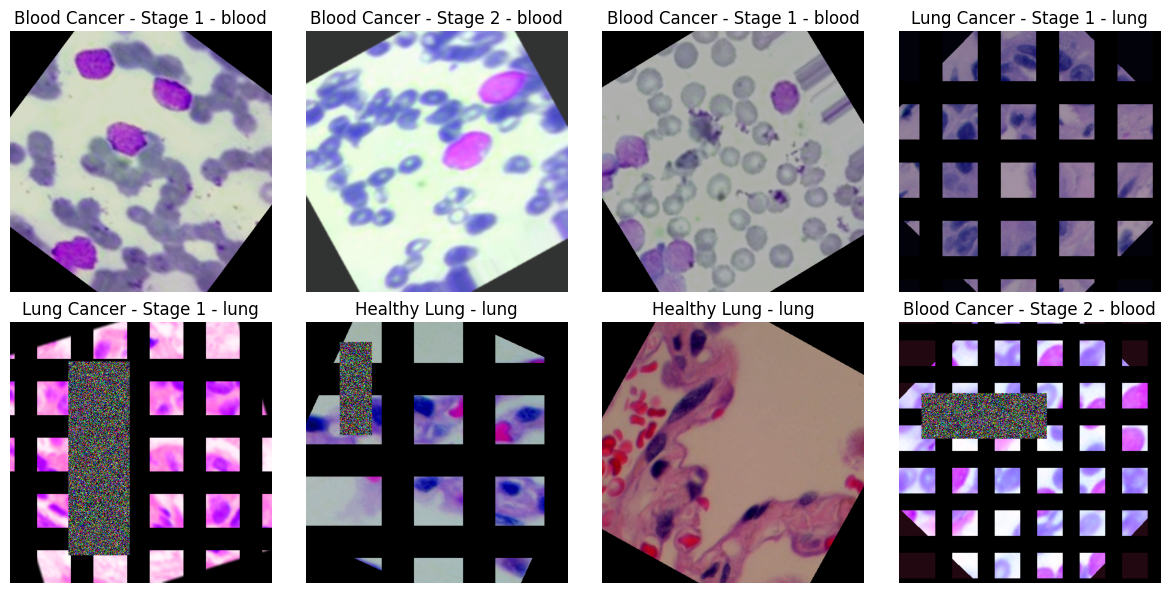

In [ ]:
def unnormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN)[:, None, None]
    std = torch.tensor(IMAGENET_STD)[:, None, None]
    image = tensor.cpu() * std + mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()

images, labels, paths, organs = next(iter(train_loader))
plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(unnormalize(images[i]))
    plt.title(f"{CLASS_DISPLAY_NAMES[labels[i].item()]} - {organs[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 8. Build the CNN Classifier

In [ ]:
def build_model(num_classes):
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=DROPOUT * 0.5),
        nn.Linear(512, num_classes),
    )
    return model

model = build_model(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
soft_criterion = nn.CrossEntropyLoss()

# Differential LR: pretrained ResNet50 layers learn gently, the new classifier learns faster.
optimizer = torch.optim.AdamW([
    {
        'params': [
            p for name, p in model.named_parameters()
            if not name.startswith('fc.')
        ],
        'lr': LEARNING_RATE * 0.10,
    },
    {
        'params': model.fc.parameters(),
        'lr': LEARNING_RATE,
    },
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print('Fine-tuning ResNet50 for histopathological image classification')
print('Backbone LR:', optimizer.param_groups[0]['lr'])
print('Classifier head LR:', optimizer.param_groups[1]['lr'])
sum(p.numel() for p in model.parameters())


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Fine-tuning ResNet50 for histopathological image classification
Backbone LR: 2.9999999999999997e-05
Classifier head LR: 0.0003


/tmp/ipykernel_504/3615932503.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


24564813

## 9. Training and Evaluation Functions

In [ ]:
def one_hot(labels, num_classes, smoothing=0.0):
    off_value = smoothing / num_classes
    on_value = 1.0 - smoothing + off_value
    targets = torch.full((labels.size(0), num_classes), off_value, device=labels.device)
    targets.scatter_(1, labels.unsqueeze(1), on_value)
    return targets

def rand_bbox(width, height, lam):
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(width * cut_ratio)
    cut_h = int(height * cut_ratio)
    cx = np.random.randint(width)
    cy = np.random.randint(height)
    x1 = np.clip(cx - cut_w // 2, 0, width)
    y1 = np.clip(cy - cut_h // 2, 0, height)
    x2 = np.clip(cx + cut_w // 2, 0, width)
    y2 = np.clip(cy + cut_h // 2, 0, height)
    return x1, y1, x2, y2

def apply_mixup_or_cutmix(images, labels):
    if random.random() > MIX_PROB:
        return images, one_hot(labels, NUM_CLASSES, LABEL_SMOOTHING)

    indices = torch.randperm(images.size(0), device=images.device)
    use_cutmix = random.random() < CUTMIX_PROB
    alpha = CUTMIX_ALPHA if use_cutmix else MIXUP_ALPHA
    lam = float(np.random.beta(alpha, alpha))

    targets_a = one_hot(labels, NUM_CLASSES, LABEL_SMOOTHING)
    targets_b = one_hot(labels[indices], NUM_CLASSES, LABEL_SMOOTHING)

    if use_cutmix:
        _, _, h, w = images.shape
        x1, y1, x2, y2 = rand_bbox(w, h, lam)
        mixed = images.clone()
        mixed[:, :, y1:y2, x1:x2] = images[indices, :, y1:y2, x1:x2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / float(w * h))
        return mixed, targets_a * lam + targets_b * (1.0 - lam)

    mixed = images * lam + images[indices] * (1.0 - lam)
    return mixed, targets_a * lam + targets_b * (1.0 - lam)

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels, *_ in tqdm(loader, desc='Training'):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mixed_images, soft_targets = apply_mixup_or_cutmix(images, labels)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(mixed_images)
            loss = soft_criterion(logits, soft_targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true, y_pred)
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    y_true = []
    y_pred = []
    y_conf = []
    meta = []

    for images, labels, paths, organs in tqdm(loader, desc='Validation'):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
        y_conf.extend(probs.max(dim=1).values.detach().cpu().numpy())
        meta.extend(list(zip(paths, organs)))

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true, y_pred)
    pred_df = pd.DataFrame(meta, columns=['path', 'organ'])
    pred_df['true_label'] = y_true
    pred_df['pred_label'] = y_pred
    pred_df['true_name'] = [CLASS_NAMES[i] for i in y_true]
    pred_df['pred_name'] = [CLASS_NAMES[i] for i in y_pred]
    pred_df['confidence'] = y_conf
    return epoch_loss, epoch_acc, pred_df


## 10. Train the Model

In [ ]:
def save_training_checkpoint(epoch, best_val_acc, history):
    torch.save({
        'epoch': epoch,
        'model_name': MODEL_NAME,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_val_acc': best_val_acc,
        'history': history,
        'img_size': IMG_SIZE,
        'class_names': CLASS_NAMES,
        'class_display_names': CLASS_DISPLAY_NAMES,
        'required_class_folders': REQUIRED_CLASS_FOLDERS,
        'num_classes': NUM_CLASSES,
        'label_smoothing': LABEL_SMOOTHING,
        'dropout': DROPOUT,
        'mixup_alpha': MIXUP_ALPHA,
        'cutmix_alpha': CUTMIX_ALPHA,
    }, CHECKPOINT_PATH)
    print('Saved resume checkpoint:', CHECKPOINT_PATH)

def load_training_checkpoint():
    if not CHECKPOINT_PATH.exists():
        print('No resume checkpoint found. Starting from epoch 1.')
        return 1, -1, []

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    if checkpoint.get('model_name') != MODEL_NAME:
        raise ValueError(
            f"Checkpoint model is {checkpoint.get('model_name')}, but current model is {MODEL_NAME}. "
            f"Delete {CHECKPOINT_PATH} if you want to train the ResNet50 version from epoch 1."
        )
    if checkpoint.get('num_classes') != NUM_CLASSES:
        raise ValueError(
            f"Checkpoint has {checkpoint.get('num_classes')} classes, "
            f"but current dataset has {NUM_CLASSES}. Delete {CHECKPOINT_PATH} if you changed the dataset."
        )
    if checkpoint.get('class_names') != CLASS_NAMES:
        raise ValueError(
            f"Checkpoint classes do not match the current dataset. Delete {CHECKPOINT_PATH} if you changed folders."
        )

    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        if 'scaler_state_dict' in checkpoint:
            scaler.load_state_dict(checkpoint['scaler_state_dict'])
    except RuntimeError as exc:
        raise RuntimeError(
            'The saved checkpoint does not match the current ResNet50 histopathology fine-tuning setup. '
            f'Delete {CHECKPOINT_PATH} and run training again from epoch 1.'
        ) from exc

    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint.get('best_val_acc', -1)
    history = checkpoint.get('history', [])

    print(f'Loaded resume checkpoint. Continuing from epoch {start_epoch}.')
    print(f'Best validation accuracy so far: {best_val_acc:.4f}')
    return start_epoch, best_val_acc, history

start_epoch, best_val_acc, history = load_training_checkpoint()

if start_epoch > EPOCHS:
    print(f'Checkpoint already completed {EPOCHS} epochs. Increase EPOCHS if you want to train longer.')

for epoch in range(start_epoch, EPOCHS + 1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_predictions = evaluate(model, val_loader)
    scheduler.step()
    backbone_lr = optimizer.param_groups[0]['lr']
    head_lr = optimizer.param_groups[1]['lr']

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'backbone_lr': backbone_lr,
        'head_lr': head_lr,
    })

    print(f'train_loss={train_loss:.4f} train_acc={train_acc:.4f}')
    print(f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} backbone_lr={backbone_lr:.2e} head_lr={head_lr:.2e}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_name': MODEL_NAME,
            'model_state_dict': model.state_dict(),
            'img_size': IMG_SIZE,
            'class_names': CLASS_NAMES,
            'class_display_names': CLASS_DISPLAY_NAMES,
            'required_class_folders': REQUIRED_CLASS_FOLDERS,
            'num_classes': NUM_CLASSES,
            'best_val_acc': best_val_acc,
            'epoch': epoch,
            'label_smoothing': LABEL_SMOOTHING,
            'dropout': DROPOUT,
        }, MODEL_SAVE_PATH)
        print('Saved best model:', MODEL_SAVE_PATH)

    save_training_checkpoint(epoch, best_val_acc, history)

history_df = pd.DataFrame(history)
display(history_df)


Loaded resume checkpoint. Continuing from epoch 38.
Best validation accuracy so far: 0.9912

Epoch 38/60


Training:   0%|          | 0/813 [00:00<?, ?it/s]

Validation:   0%|          | 0/163 [00:00<?, ?it/s]

train_loss=0.7309 train_acc=0.8303
val_loss=0.4799 val_acc=0.9877 backbone_lr=9.60e-06 head_lr=8.97e-05
Saved resume checkpoint: /content/drive/MyDrive/siamese_multi/last_resnet50_histopathology_checkpoint.pth

Epoch 39/60


Training:   0%|          | 0/813 [00:00<?, ?it/s]

...

train_loss=0.7157 train_acc=0.8215
val_loss=0.4747 val_acc=0.9915 backbone_lr=1.02e-06 head_lr=1.20e-06
Saved resume checkpoint: /content/drive/MyDrive/siamese_multi/last_resnet50_histopathology_checkpoint.pth

Epoch 60/60


Training:   0%|          | 0/813 [00:00<?, ?it/s]

Validation:   0%|          | 0/163 [00:00<?, ?it/s]

train_loss=0.7279 train_acc=0.8079
val_loss=0.4730 val_acc=0.9931 backbone_lr=1.00e-06 head_lr=1.00e-06
Saved best model: /content/drive/MyDrive/siamese_multi/best_resnet50_histopathology_gradcam_classifier.pth
Saved resume checkpoint: /content/drive/MyDrive/siamese_multi/last_resnet50_histopathology_checkpoint.pth


,epoch,train_loss,train_acc,val_loss,val_acc,backbone_lr,head_lr
0,1,1.366430,0.586769,0.621460,0.951154,0.000030,0.000300
1,2,1.093816,0.708923,0.601608,0.947308,0.000030,0.000299
2,3,1.026765,0.718615,0.587721,0.948077,0.000030,0.000298
3,4,0.986483,0.731615,0.544550,0.968462,0.000030,0.000297
4,5,0.961405,0.738692,0.548298,0.962308,0.000030,0.000295
5,6,0.922887,0.739462,0.526906,0.972308,0.000029,0.000293
6,7,0.920833,0.768846,0.536891,0.967308,0.000029,0.000290
7,8,0.886748,0.786923,0.535133,0.971923,0.000029,0.000287
8,9,0.899757,0.760077,0.526335,0.970385,0.000028,0.000284
9,10,0.877373,0.783692,0.523149,0.974615,0.000028,0.000280


## 11. Training Curves

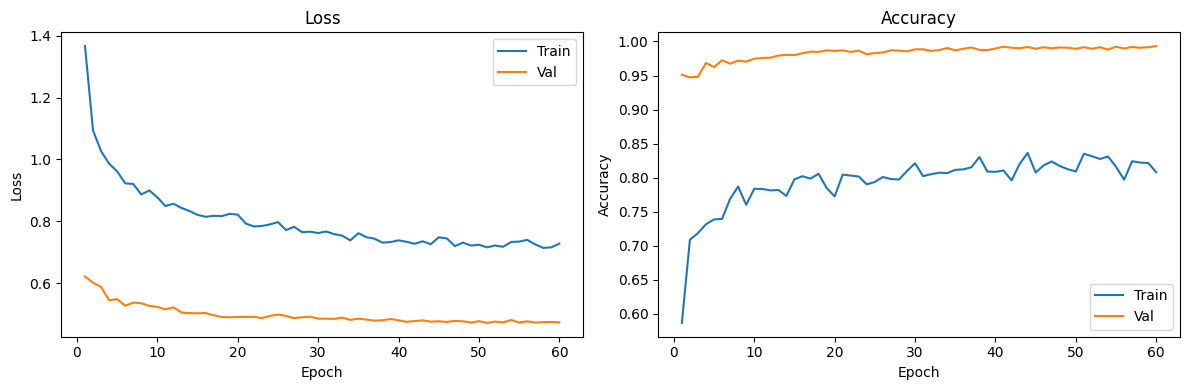

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train')
plt.plot(history_df['epoch'], history_df['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['train_acc'], label='Train')
plt.plot(history_df['epoch'], history_df['val_acc'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 12. Final Validation Report

In [ ]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_loss, val_acc, val_predictions = evaluate(model, val_loader)
print('Best validation accuracy:', val_acc)
print(classification_report(
    val_predictions['true_label'],
    val_predictions['pred_label'],
    target_names=CLASS_DISPLAY_NAMES,
))
print('Confusion matrix:')
print(confusion_matrix(val_predictions['true_label'], val_predictions['pred_label']))

display(
    val_predictions.assign(correct=val_predictions.true_label == val_predictions.pred_label)
    .groupby('organ')['correct']
    .mean()
    .mul(100)
    .reset_index(name='accuracy_percent')
)

Validation:   0%|          | 0/163 [00:00<?, ?it/s]

Best validation accuracy: 0.9930769230769231
                        precision    recall  f1-score   support

Blood Cancer - Stage 1       1.00      1.00      1.00       200
Blood Cancer - Stage 2       1.00      1.00      1.00       200
Blood Cancer - Stage 3       1.00      1.00      1.00       200
         Breast Cancer       0.97      0.96      0.96       200
          Colon Cancer       1.00      1.00      1.00       200
         Kidney Cancer       1.00      1.00      1.00       200
 Lung Cancer - Stage 1       1.00      0.99      0.99       200
 Lung Cancer - Stage 2       0.99      1.00      0.99       200
         Healthy Blood       1.00      0.99      1.00       200
        Healthy Breast       0.97      0.97      0.97       200
         Healthy Colon       1.00      1.00      1.00       200
        Healthy Kidney       1.00      0.99      1.00       200
          Healthy Lung       1.00      1.00      1.00       200

              accuracy                           0.99    

,organ,accuracy_percent
0,blood,99.875000
1,breast,96.500000
2,colon,100.000000
3,kidney,99.750000
4,lung,99.666667


## 13. Grad-CAM Setup

Grad-CAM hooks into the last residual block of ResNet50: `model.layer4[-1]`.
This is the deepest convolutional layer before the global average pooling,
which produces the most semantically meaningful activations for localisation.


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
        logits = self.model(image_tensor)
        probs = F.softmax(logits, dim=1)[0]

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = F.interpolate(
            cam[None, None],
            size=(IMG_SIZE, IMG_SIZE),
            mode='bilinear',
            align_corners=False,
        )[0, 0]
        return cam.cpu().numpy(), probs.detach().cpu().numpy(), class_idx

# ResNet50: correct target layer is model.layer4[-1] (last residual block)
gradcam = GradCAM(model, model.layer4[-1])


## 14. Test One Image with Grad-CAM

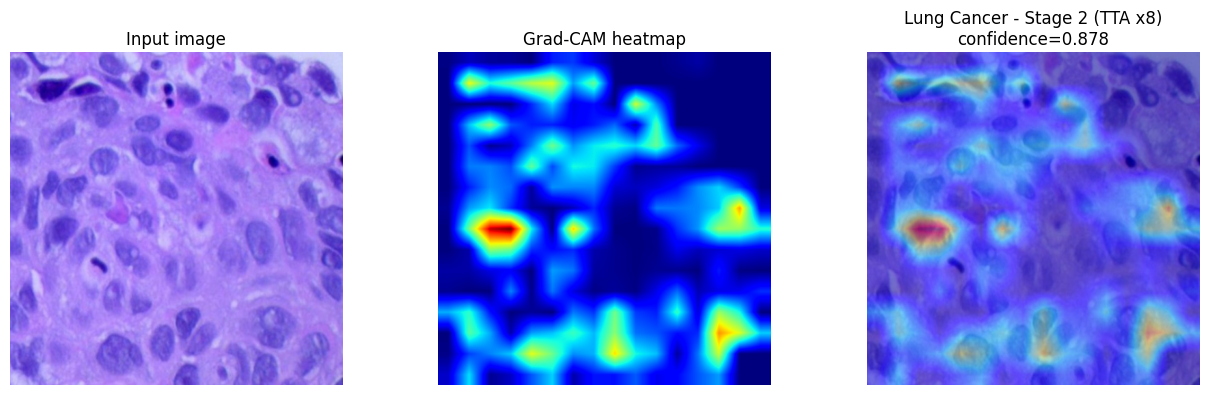

{'image_path': '/content/images/cancersv4/val/cancer_lung_stage_2/lung_scc_1194.jpg',
 'prediction': 'Lung Cancer - Stage 2',
 'confidence': 0.8779296875,
 'tta_used': True,
 'tta_n': 8,
 'probabilities': {'Blood Cancer - Stage 1': 0.007785797119140625,
  'Blood Cancer - Stage 2': 0.0096435546875,
  'Blood Cancer - Stage 3': 0.00804901123046875,
  'Breast Cancer': 0.01010894775390625,
  'Colon Cancer': 0.00884246826171875,
  'Kidney Cancer': 0.01074981689453125,
  'Lung Cancer - Stage 1': 0.0211029052734375,
  'Lung Cancer - Stage 2': 0.8779296875,
  'Healthy Blood': 0.009552001953125,
  'Healthy Breast': 0.0087890625,
  'Healthy Colon': 0.00933837890625,
  'Healthy Kidney': 0.0091094970703125,
  'Healthy Lung': 0.008941650390625}}

In [ ]:
def predict_with_gradcam(image_path, use_tta=True, tta_n=8):
    """Predict a single image with Grad-CAM heatmap.

    Args:
        image_path: path to the image file.
        use_tta: if True, average predictions over multiple augmented views
                 (Test-Time Augmentation) for more robust inference.
        tta_n: number of augmented views to average when use_tta=True.
    """
    image = Image.open(image_path).convert('RGB')

    if use_tta:
        model.eval()
        tta_probs = []
        with torch.no_grad():
            for _ in range(tta_n):
                x_tta = tta_transforms(image).unsqueeze(0).to(DEVICE)
                with torch.amp.autocast('cuda', enabled=USE_AMP):
                    logits_tta = model(x_tta)
                tta_probs.append(F.softmax(logits_tta, dim=1).cpu())
        avg_probs = torch.stack(tta_probs).mean(0)[0].numpy()
        tta_class_idx = int(avg_probs.argmax())
    else:
        avg_probs = None
        tta_class_idx = None

    # Grad-CAM uses the standard val transform (deterministic)
    x = val_transforms(image)
    cam, base_probs, gradcam_class_idx = gradcam(x)

    # Use TTA probabilities for display if available; fall back to single-pass
    display_probs = avg_probs if use_tta else base_probs
    display_class_idx = tta_class_idx if use_tta else gradcam_class_idx

    display_img = unnormalize(x)
    class_names = CLASS_DISPLAY_NAMES

    result = {
        'image_path': image_path,
        'prediction': class_names[display_class_idx],
        'confidence': float(display_probs[display_class_idx]),
        'tta_used': use_tta,
        'tta_n': tta_n if use_tta else 0,
        'probabilities': {class_names[i]: float(display_probs[i]) for i in range(len(class_names))},
    }

    plt.figure(figsize=(13, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(display_img)
    plt.title('Input image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap='jet')
    plt.title('Grad-CAM heatmap')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(display_img)
    plt.imshow(cam, cmap='jet', alpha=0.45)
    tta_label = f' (TTA x{tta_n})' if use_tta else ''
    plt.title(f"{result['prediction']}{tta_label}\nconfidence={result['confidence']:.3f}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    return result

# Automatically choose one validation image. Replace this with your own image path if you want.
TEST_IMAGE = val_df.sample(1, random_state=SEED).iloc[0].path
predict_with_gradcam(TEST_IMAGE, use_tta=True, tta_n=8)


## 15. Show Several Grad-CAM Examples

In [ ]:
sample_df = val_df.groupby(['label_name', 'organ'], group_keys=False).apply(
    lambda x: x.sample(min(1, len(x)), random_state=SEED)
).reset_index(drop=True)

for image_path in sample_df.path.tolist():
    print(image_path)
    predict_with_gradcam(image_path)

## How to Use the Trained Model Later

After training, the best CNN classifier is saved as:

```text
best_cnn_gradcam_classifier.pth
```

This model can become the first stage of your full pipeline. The next stage can pass the same input image into your Siamese model to find similar known cancer or healthy patches.